In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from scipy.spatial.distance import squareform

from statsmodels.stats.multitest import multipletests

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler, Normalizer


import xgboost as xgb
import shap


import joblib
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from contextlib import contextmanager

import importlib
import bootstrap_v2
import distribution_estimation
import plotting

# from math import erf
# from math import lgamma

importlib.reload(bootstrap_v2)
importlib.reload(distribution_estimation)
importlib.reload(plotting)

from bootstrap_v2 import *
from distribution_estimation import *
from plotting import *

/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
params = {
    #'booster':'gbtree',
        #'silent':0, # 1 - info output; 0 - silent
        #'scale_pos_weight': 33, # If value > 0, helps with fast convergence in case of imbalanced class samples
        'objective': 'binary:logistic', # for binary classification
        'seed':2, # random seed
        'eval_metric': 'logloss',  # binary logloss
        'eta': 0.5, # learning rate
        'max_depth': 20,
        'min_child_weight': 0.2,
        'subsample': 0.8, 
        'colsample_bytree': 0.6,
        #'gamma': 0.418,
        #'lambda': 1.814,
        #'alpha': 3.17,
       }

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_binary_data_controlled(
    n_samples=300,          # N
    n_features=20,          # p, default p < N
    important_idx=(0, 1, 2, 3),
    correlated_pair=(0, 1), # these two will be highly correlated and important
    rho=0.9,                # target correlation for the pair
    signal_strength=1.0,
    noise_scale=0.8,
    random_state=42,
):
    """
    Simulate binary classification data with controlled important variables.

    Features:
    - User controls which variables are important
    - Two chosen variables can be made highly correlated
    - Binary y generated from a partly nonlinear logistic model

    Returns
    -------
    X : pd.DataFrame
    y : pd.Series
    meta : dict
    """
    rng = np.random.default_rng(random_state)

    if n_features >= n_samples:
        print("Warning: p >= N in this run. You said start with p < N.")

    important_idx = tuple(important_idx)
    correlated_pair = tuple(correlated_pair)

    if len(set(correlated_pair)) != 2:
        raise ValueError("correlated_pair must contain exactly two distinct indices.")

    if not set(correlated_pair).issubset(set(important_idx)):
        raise ValueError("correlated_pair should be included in important_idx.")

    if max(important_idx) >= n_features or min(important_idx) < 0:
        raise ValueError("important_idx contains invalid feature indices.")

    # -----------------------------
    # 1. generate mostly independent features
    # -----------------------------
    X = rng.normal(size=(n_samples, n_features))

    # -----------------------------
    # 2. overwrite the correlated important pair
    #    so they have approximately corr = rho
    # -----------------------------
    z = rng.normal(size=n_samples)
    e1 = rng.normal(size=n_samples)
    e2 = rng.normal(size=n_samples)

    j1, j2 = correlated_pair
    X[:, j1] = z
    X[:, j2] = rho * z + np.sqrt(max(1 - rho**2, 1e-8)) * e2

    # standardize columns
    X = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)
    X = np.nan_to_num(X)

    # -----------------------------
    # 3. build binary outcome
    #    important variables only
    # -----------------------------
    # label the important variables for readability
    # first two are the correlated important pair
    x0 = X[:, important_idx[0]]
    x1 = X[:, important_idx[1]]

    # optionally use more important features if provided
    x2 = X[:, important_idx[2]] if len(important_idx) > 2 else 0.0
    x3 = X[:, important_idx[3]] if len(important_idx) > 3 else 0.0

    # simple but not fully obvious relationship:
    # - x0 and x1 are both important and correlated
    # - x2*x3 adds interaction
    # - x2^2 adds mild nonlinearity
    # - threshold on x3 adds a step effect
    eta = (
        1.2 * x0
        + 1* x1
        + 1 * (x2 * x3)
        # - 1 * (x2 ** 2 - 1.0)
        + 2 * np.sin(1.5 * x2)
        + 2.3 * (x3 > 0).astype(float)
    )

    eta = signal_strength * eta + noise_scale * rng.normal(size=n_samples)
    eta = eta - np.median(eta)   # helps keep classes more balanced

    p = sigmoid(eta)
    y = rng.binomial(1, p, size=n_samples)

    feature_names = [f"x{j}" for j in range(n_features)]
    X = pd.DataFrame(X, columns=feature_names)
    y = pd.Series(y, name="y")

    meta = {
        "important_idx": list(important_idx),
        "important_features": [feature_names[j] for j in important_idx],
        "correlated_pair_idx": list(correlated_pair),
        "correlated_pair_features": [feature_names[j] for j in correlated_pair],
        "target_rho": rho,
        "realized_corr_pair": float(np.corrcoef(X.iloc[:, j1], X.iloc[:, j2])[0, 1]),
        "eta": eta,
        "prob": p,
        "true_model": (
            "logit(P(Y=1)) = 1.2*x0 + 1.0*x1 + 1.0*(x2*x3) "
            "+ 2.0*sin(1.5*x2) + 2.3*I(x3>0) + noise"
        ),
    }

    return X, y, meta

In [3]:
def simulate_binary_data_controlled(
    n_samples=300,
    n_features=20,
    important_idx=(0, 1, 2, 3),
    correlated_pair=(0, 1),
    rho=0.9,
    signal_strength=1.0,
    noise_scale=0.8,
    # Explicit effect sizes — directly comparable after standardization
    weights=(3.0, 2.0, 1.5, 1.0, 0.5),
    # corresponds to: x0, x1, x2*x3, sin(x2), I(x3>0)
    random_state=42,
):
    """
    Simulate binary classification data.

    Effect sizes (after standardizing each term to unit variance):
        x0          : weights[0]  — largest linear effect
        x1          : weights[1]  — second linear effect (correlated with x0)
        x2 * x3     : weights[2]  — interaction effect
        sin(1.5*x2) : weights[3]  — nonlinear effect
        I(x3 > 0)   : weights[4]  — threshold effect

    All weights are directly comparable — larger absolute value = larger effect.
    """
    rng = np.random.default_rng(random_state)

    important_idx = tuple(important_idx)
    correlated_pair = tuple(correlated_pair)

    if len(set(correlated_pair)) != 2:
        raise ValueError("correlated_pair must contain exactly two distinct indices.")
    if not set(correlated_pair).issubset(set(important_idx)):
        raise ValueError("correlated_pair should be included in important_idx.")
    if max(important_idx) >= n_features or min(important_idx) < 0:
        raise ValueError("important_idx contains invalid feature indices.")

    j1, j2 = correlated_pair

    # ------------------------------------------------------------------
    # 1. Build orthogonal basis via QR
    # ------------------------------------------------------------------
    rand_matrix = rng.normal(size=(n_samples, n_features))
    Q, _ = np.linalg.qr(rand_matrix)
    basis = Q * np.sqrt(n_samples)

    # ------------------------------------------------------------------
    # 2. Build correlated pair
    # ------------------------------------------------------------------
    b1 = basis[:, j1].copy()
    b2 = basis[:, j2].copy()
    col_j1 = b1
    col_j2 = rho * b1 + np.sqrt(max(1 - rho**2, 1e-8)) * b2

    X = basis.copy()
    X[:, j1] = col_j1
    X[:, j2] = col_j2

    # Standardize all columns to mean=0, std=1
    X = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)
    X = np.nan_to_num(X)

    # ------------------------------------------------------------------
    # 3. Build eta with standardized terms and explicit weights
    # ------------------------------------------------------------------
    x0 = X[:, important_idx[0]]
    x1 = X[:, important_idx[1]]
    x2 = X[:, important_idx[2]] if len(important_idx) > 2 else np.zeros(n_samples)
    x3 = X[:, important_idx[3]] if len(important_idx) > 3 else np.zeros(n_samples)

    # Raw terms
    t0 = x0                          # linear
    t1 = x1                          # linear (correlated with t0)
    t2 = x2 * x3                     # interaction
    t3 = np.sin(1.5 * x2)            # nonlinear
    t4 = (x3 > 0).astype(float)      # threshold

    # Standardize each term to unit variance
    # so weights are true effect sizes
    def _std_term(t):
        s = t.std()
        return t / s if s > 1e-8 else t

    t0s = _std_term(t0)
    t1s = _std_term(t1)
    t2s = _std_term(t2)
    t3s = _std_term(t3)
    t4s = _std_term(t4)

    w0, w1, w2, w3, w4 = weights

    eta = (
        w0 * t0s +
        w1 * t1s +
        w2 * t2s +
        w3 * t3s +
        w4 * t4s
    )

    eta = signal_strength * eta + noise_scale * rng.normal(size=n_samples)
    eta = eta - np.median(eta)

    p = sigmoid(eta)
    y = rng.binomial(1, p, size=n_samples)

    feature_names = [f"x{j}" for j in range(n_features)]
    X_df = pd.DataFrame(X, columns=feature_names)
    y_s = pd.Series(y, name="y")

    # Realized correlations
    corr_matrix = X_df.corr()
    realized_rho = corr_matrix.iloc[j1, j2]
    mask = np.ones((n_features, n_features), dtype=bool)
    mask[j1, j2] = False
    mask[j2, j1] = False
    np.fill_diagonal(mask, False)
    max_other_corr = corr_matrix.values[mask].max()

    meta = {
        "important_idx": list(important_idx),
        "important_features": [feature_names[j] for j in important_idx],
        "correlated_pair_idx": list(correlated_pair),
        "correlated_pair_features": [feature_names[j] for j in correlated_pair],
        "target_rho": rho,
        "realized_corr_pair": float(realized_rho),
        "max_other_corr": float(max_other_corr),
        "weights": dict(zip(["x0", "x1", "x2*x3", "sin(x2)", "I(x3>0)"], weights)),
        "true_effect_ranking": sorted(
            zip(["x0", "x1", "x2*x3", "sin(x2)", "I(x3>0)"], weights),
            key=lambda x: abs(x[1]), reverse=True
        ),
        "eta": eta,
        "prob": p,
        "true_model": (
            f"logit(P(Y=1)) = {w0}*x0_std + {w1}*x1_std + {w2}*(x2*x3)_std "
            f"+ {w3}*sin(1.5*x2)_std + {w4}*I(x3>0)_std + noise"
        ),
    }

    return X_df, y_s, meta

# Feature importance switching because of seed and train-test split

## Example 1 - seed

In [4]:
# X_simple1, y_simple1, meta_simple = simulate_binary_data_controlled(
#     n_samples=300,          # N
#     n_features=4,          # p, default p < N
#     important_idx=(0, 1, 2, 3),
#     correlated_pair=(2, 3), # these two will be highly correlated and important
#     rho=0.7,                # target correlation for the pair
#     signal_strength=1.0,
#     noise_scale=0.25,
#     weights = (1.0, 2.0, 0, 3, 3.5),
#     random_state=42,
# )

# print(X_simple1.shape)
# print(y_simple1.value_counts())

In [5]:
X_simple1, y_simple1, meta_simple = simulate_binary_data_controlled(
    n_samples=300,          # N
    n_features=4,          # p, default p < N
    important_idx=(0, 1, 2, 3),
    correlated_pair=(0, 1), # these two will be highly correlated and important
    rho=-0.7,                # target correlation for the pair
    signal_strength=1.0,
    noise_scale=0.5,
    weights = (1.5, 2.0, 0, 3, 3.5),
    random_state=42,
)

print(meta_simple.get("true_effect_ranking"))

[('I(x3>0)', 3.5), ('sin(x2)', 3), ('x1', 2.0), ('x0', 1.5), ('x2*x3', 0)]


In [6]:
x2 = X_simple1['x2'].values
x3 = X_simple1['x3'].values

t2 = x2 * x3
t3 = np.sin(1.5 * x2)
t4 = (x3 > 0).astype(float)

print("corr(x2, x2*x3):", np.corrcoef(x2, t2)[0,1])
print("corr(x2, sin(x2)):", np.corrcoef(x2, t3)[0,1])
print("corr(x3, I(x3>0)):", np.corrcoef(x3, t4)[0,1])

corr(x2, x2*x3): -0.03181148887215033
corr(x2, sin(x2)): 0.710331614825456
corr(x3, I(x3>0)): 0.8028394045387188


In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_simple1, y_simple1, test_size=0.2, random_state=42, stratify=y_simple1)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

NameError: name 'X_simple1' is not defined

In [8]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.50592+0.02149	test-logloss:0.59373+0.02782
[1]	train-logloss:0.39837+0.01028	test-logloss:0.54983+0.04701
[2]	train-logloss:0.32293+0.01202	test-logloss:0.52223+0.05917
[3]	train-logloss:0.23567+0.00625	test-logloss:0.42496+0.05166
[4]	train-logloss:0.19026+0.00568	test-logloss:0.37841+0.05085
[5]	train-logloss:0.16356+0.00473	test-logloss:0.36835+0.05432
[6]	train-logloss:0.14525+0.00472	test-logloss:0.36921+0.05301
[7]	train-logloss:0.12702+0.00566	test-logloss:0.36494+0.05042
[8]	train-logloss:0.11392+0.00461	test-logloss:0.36833+0.05718
[9]	train-logloss:0.10065+0.00328	test-logloss:0.35752+0.06867
[10]	train-logloss:0.08915+0.00382	test-logloss:0.35647+0.07390
[11]	train-logloss:0.08079+0.00286	test-logloss:0.35234+0.07789
[12]	train-logloss:0.07325+0.00185	test-logloss:0.35877+0.07961
[13]	train-logloss:0.06623+0.00232	test-logloss:0.34590+0.07446
[14]	train-logloss:0.06202+0.00255	test-logloss:0.34335+0.0762

/tmp/ipykernel_3013912/1029953288.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


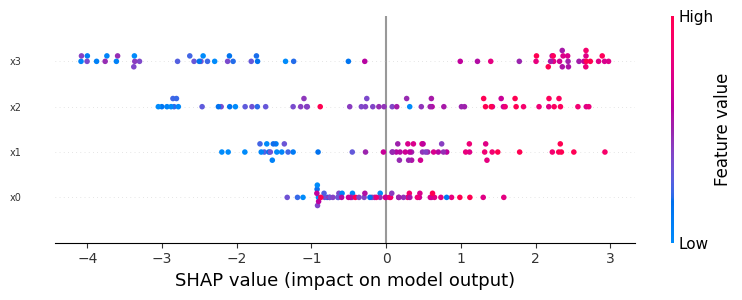

In [9]:
shap_values = model.predict(
    dtest,
    pred_contribs=True
)
plt.figure(figsize=(12, 16))
shap.summary_plot(
    shap_values[:, :-1],
    X_test,
    max_display=15,
    show=False
)

plt.yticks(fontsize=7)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
all_boot_results1 = boot_multi_repeat_inference_keep_all(
    X=X_simple1,
    y=y_simple1,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=50,
    b_model=20,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats: 100%|██████████| 50/50 [00:12<00:00,  4.01it/s]


In [11]:
mix_df1 = estimate_zero_normal_mixture(all_boot_results1)

In [12]:
sample_id = 3
feature = "x2"
row = mix_df1[
    (mix_df1["sample_id"] == sample_id) &
    (mix_df1["feature"] == feature)
].iloc[0]

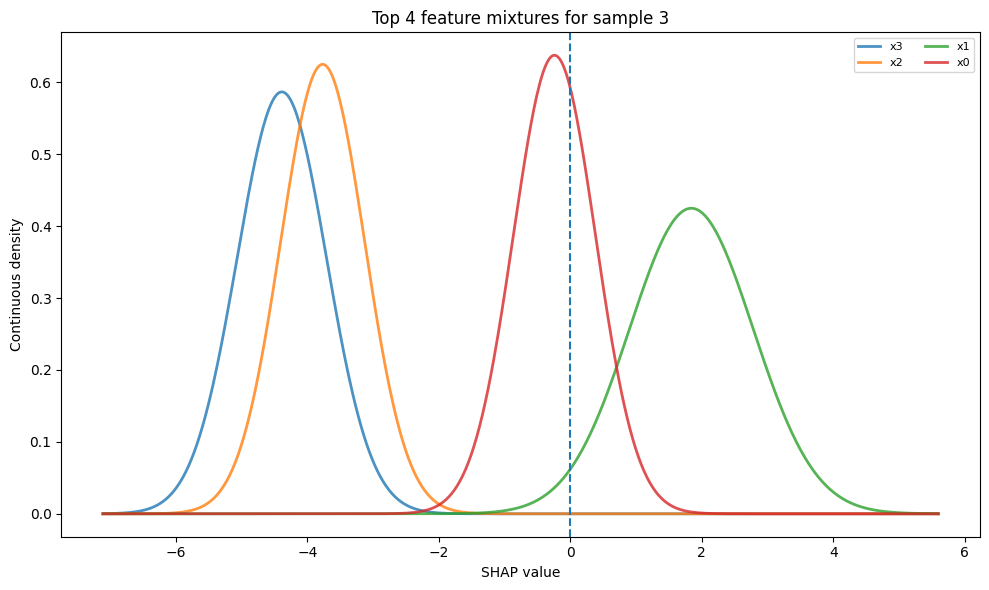

In [13]:
top15_df = plot_top_features_overlay(
    mix_df=mix_df1,
    sample_id=sample_id,
    top_k=15,
    rank_by="mean_abs_mixture",
)

In [14]:
feature_sq_df = estimate_feature_level_sq_mixture_gamma(
    boot_results=all_boot_results1,
    sample_col="sample_id",
    feature_col="feature",
    use_sample_var=True,
)

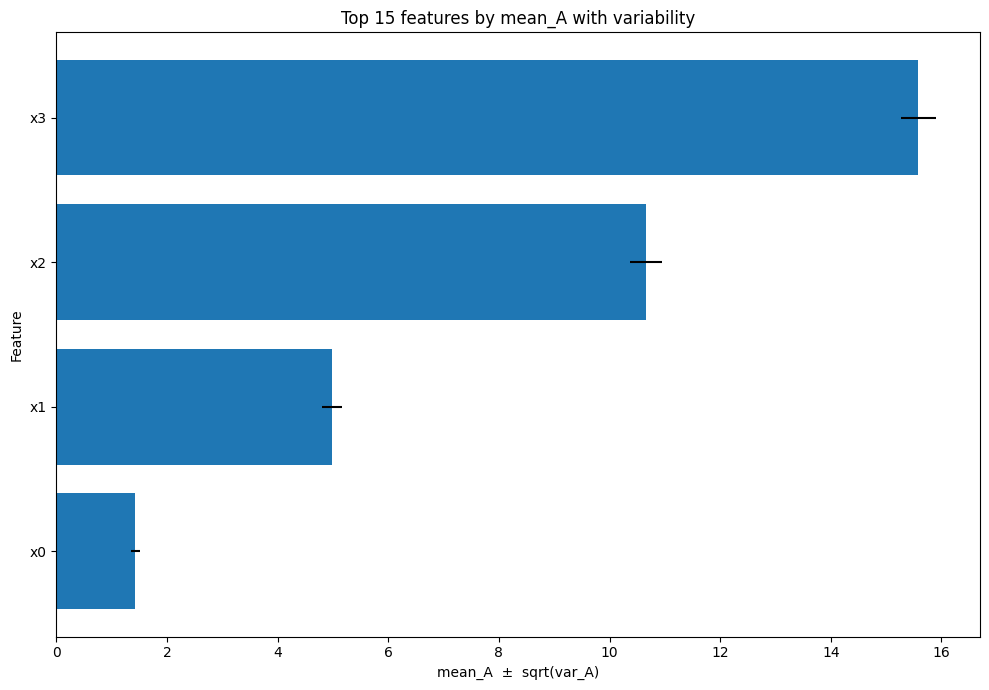

In [15]:
top15_df = plot_top15_feature_sq_with_error(
    feature_sq_df,
    top_k=15,
    score_col="mean_A",
    var_col="var_A",
)

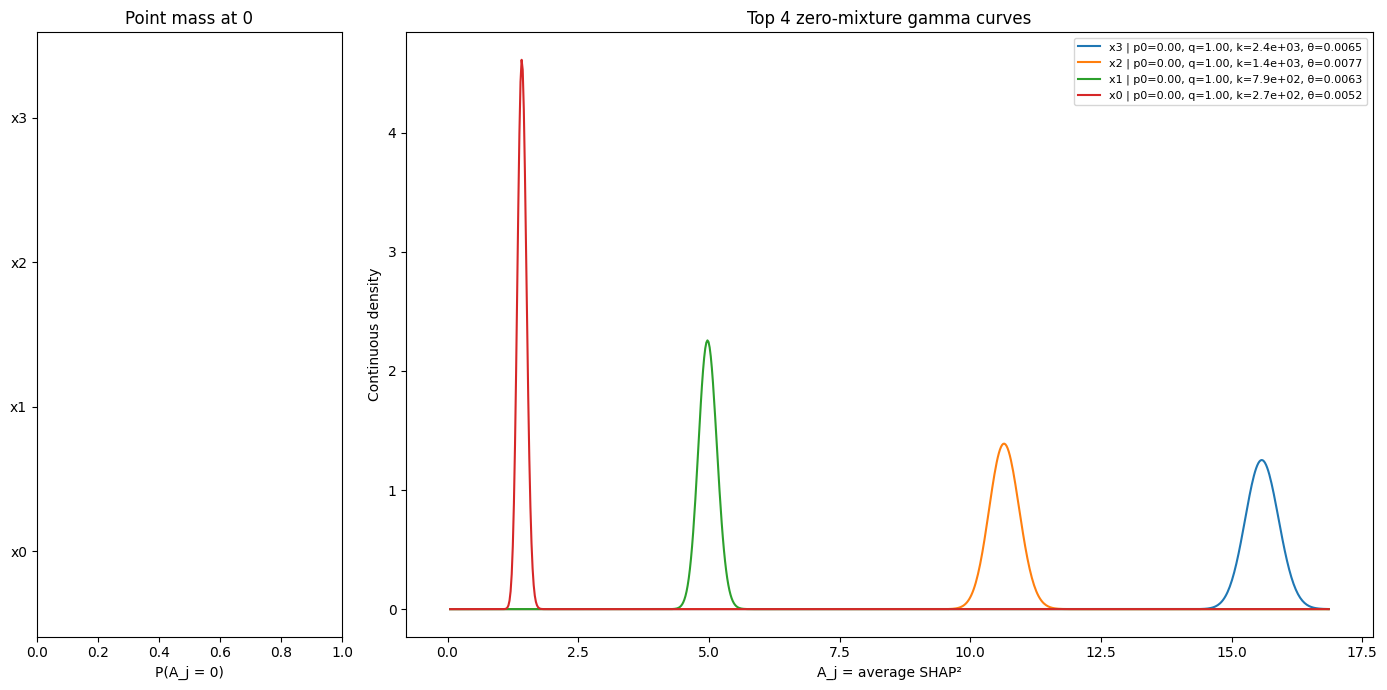

In [16]:
top_df = plot_top15_feature_sq_mixture_gamma(
    feature_sq_df,
    top_k=16,
    score_col="mean_A",
    x_min=5e-2,
    log_x=False,
)

In [17]:
all_boot_results1_2 = boot_multi_repeat_inference_keep_all(
    X=X_simple1.drop(columns=["x1"]),  # drop one feature to test robustness
    y=y_simple1,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=50,
    b_model=20,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats: 100%|██████████| 50/50 [00:08<00:00,  5.71it/s]


In [18]:
mix_df1_2 = estimate_zero_normal_mixture(all_boot_results1_2)

In [19]:
sample_id = 3
feature = "x2"
row = mix_df1_2[
    (mix_df1_2["sample_id"] == sample_id) &
    (mix_df1_2["feature"] == feature)
].iloc[0]

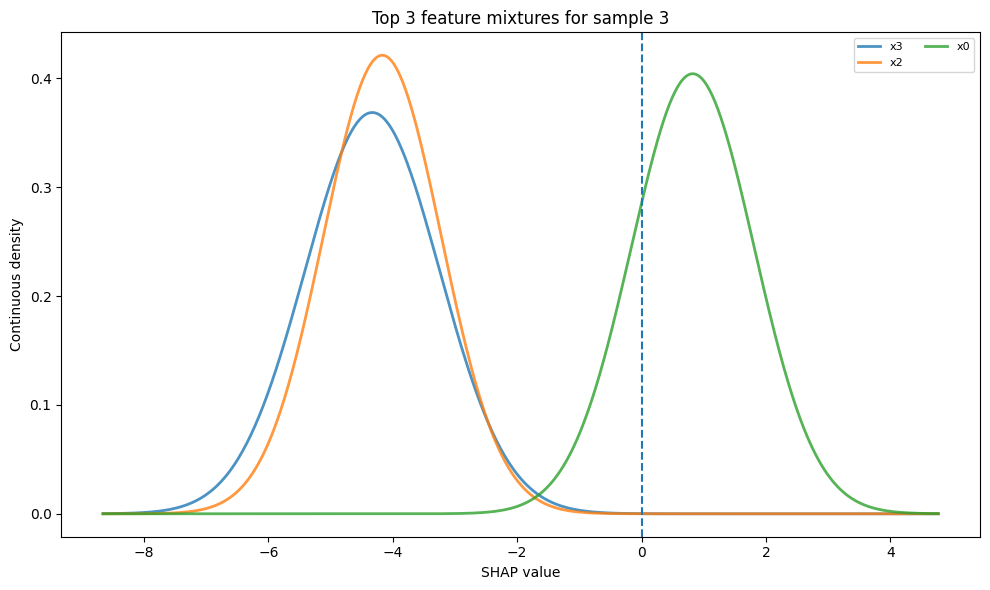

In [20]:
top15_df = plot_top_features_overlay(
    mix_df=mix_df1_2,
    sample_id=sample_id,
    top_k=15,
    rank_by="mean_abs_mixture",
)

In [21]:
feature_sq_df2 = estimate_feature_level_sq_mixture_gamma(
    boot_results=all_boot_results1_2,
    sample_col="sample_id",
    feature_col="feature",
    use_sample_var=True,
)

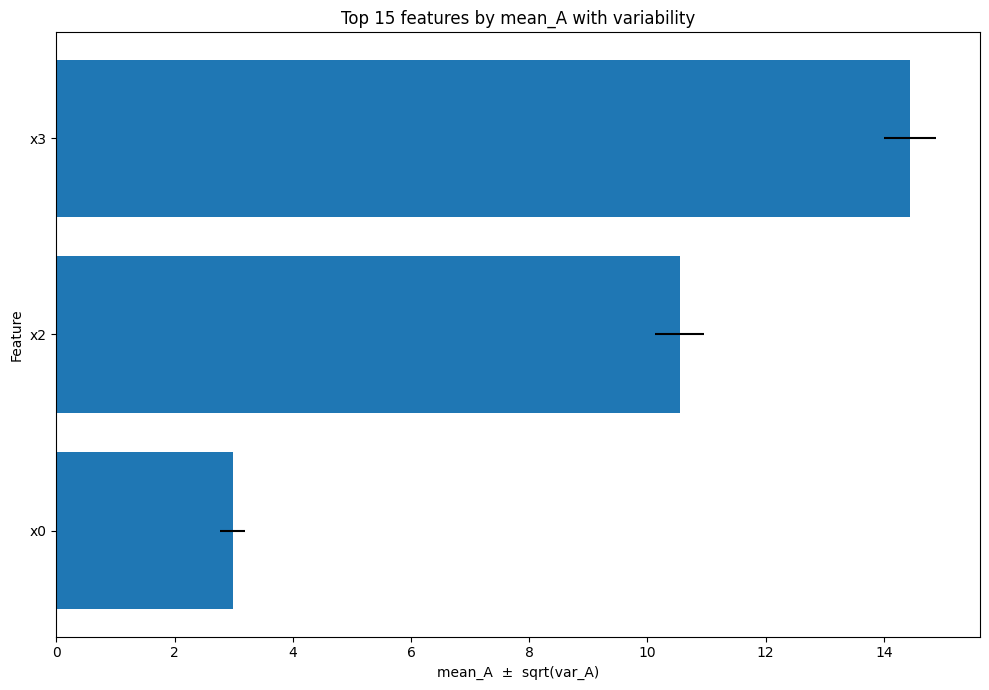

In [22]:
top15_df2 = plot_top15_feature_sq_with_error(
    feature_sq_df2,
    top_k=15,
    score_col="mean_A",
    var_col="var_A",
)

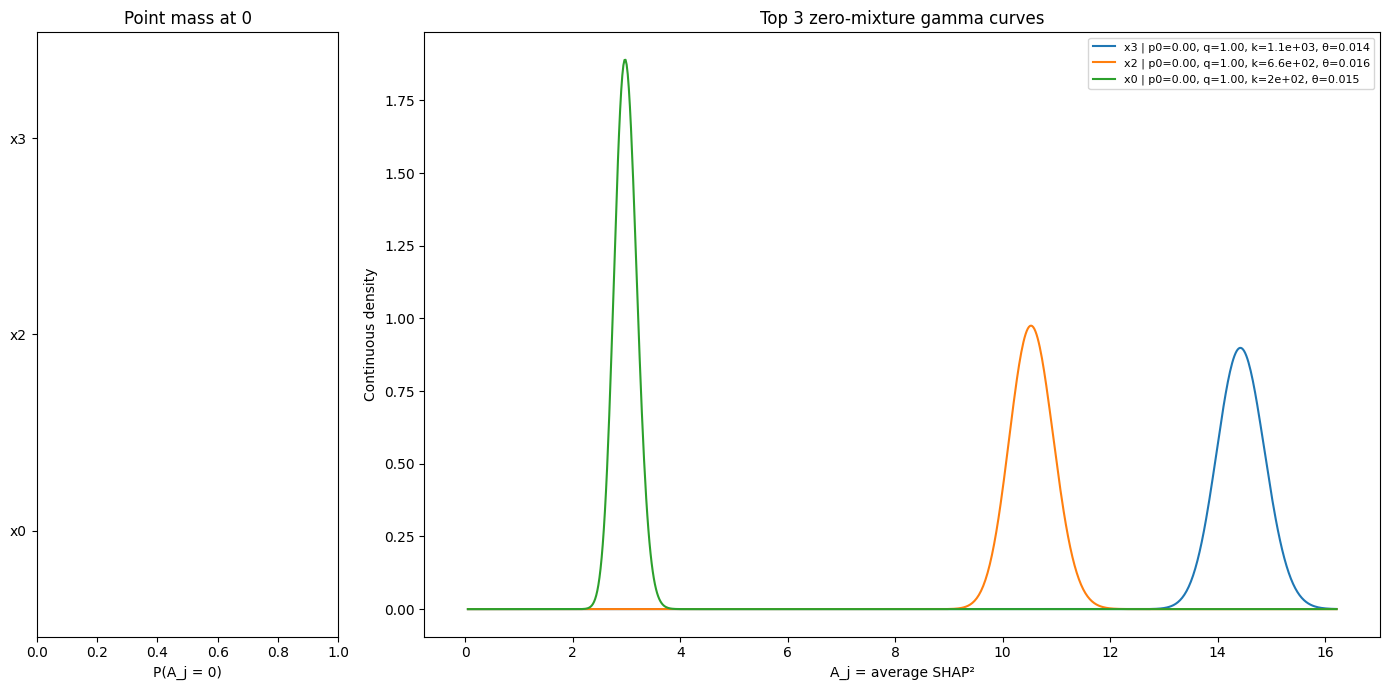

In [23]:
top_df2 = plot_top15_feature_sq_mixture_gamma(
    feature_sq_df2,
    top_k=16,
    score_col="mean_A",
    x_min=5e-2,
    log_x=False,
)

In [24]:
all_boot_results1_3 = boot_multi_repeat_inference_keep_all(
    X=X_simple1.drop(columns=["x0"]),  # drop one feature to test robustness
    y=y_simple1,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=50,
    b_model=20,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats: 100%|██████████| 50/50 [00:08<00:00,  5.88it/s]


In [4]:
X_hard, y_hard, meta_hard = simulate_binary_data_controlled(
    n_samples=100,          # small n
    n_features=20,          # p > n/5, harder regime
    important_idx=(0, 1, 2, 3),
    correlated_pair=(0, 1),
    rho=-0.75,                # high correlation
    signal_strength=1.0,
    noise_scale=0.5,
    weights=(1.0, 1.5, 4.0, 0, 0.0),
    # x0: weak linear    (1.0)
    # x1: weak linear    (1.5)  <- should rank above x0
    # x2*x3: strong interaction (4.0)
    # sin(x2): strong nonlinear (4.5) <- largest
    # I(x3>0): zero effect
    random_state=42,
)

In [5]:
(X_hard.iloc[:, 2]*X_hard.iloc[:,3]).corr(y_hard)

0.5905624162331459

In [6]:
(X_hard.iloc[:, 16]).corr(y_hard)

0.15747492079164763

In [7]:
X_hard.iloc[:, 2].corr(X_hard.iloc[:,3])

0.004006781254325624

In [8]:
def standardize_df(df):
    return (df - df.mean()) / df.std(ddof=0)
X_standardized = standardize_df(X_hard)

In [13]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# --- Build distance matrix from absolute correlation ---
abs_corr = X_standardized.corr(method='pearson').abs()
distance_matrix = 1 - abs_corr  # correlation 0.7 → distance 0.3

# Ensure symmetry and zero diagonal (numerical safety)
np.fill_diagonal(distance_matrix.values, 0)
condensed_dist = squareform(distance_matrix.values, checks=False)

# --- Hierarchical clustering with complete linkage ---
Z = linkage(condensed_dist, method='complete')

# --- Cut tree: distance threshold = 1 - correlation_threshold ---
correlation_threshold = 0.7
distance_threshold = 1 - correlation_threshold  # = 0.3

labels = fcluster(Z, t=distance_threshold, criterion='distance')

# --- Build result DataFrame ---
cluster_df = pd.DataFrame({
    'x': X_standardized.columns,
    'cluster': labels
})

# --- Verification: confirm all pairs within each cluster satisfy threshold ---
violations = 0
for cluster_id in cluster_df['cluster'].unique():
    genes_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['x'].tolist()
    if len(genes_in_cluster) < 2:
        continue
    cluster_corr = abs_corr.loc[genes_in_cluster, genes_in_cluster]
    min_corr = cluster_corr.values[np.triu_indices_from(cluster_corr.values, k=1)].min()
    if min_corr < correlation_threshold:
        violations += 1
        print(f"  Cluster {cluster_id}: min pairwise correlation = {min_corr:.3f} ← VIOLATION")

print(f"Violations: {violations}")  # Should always be 0

# --- Summary stats ---
cluster_sizes = cluster_df['cluster'].value_counts()
print(f"Correlation threshold:  {correlation_threshold}")
print(f"Number of clusters:     {cluster_df['cluster'].nunique()}")
print(f"Mean cluster size:      {cluster_sizes.mean():.2f}")
print(f"Median cluster size:    {cluster_sizes.median():.2f}")
print(f"Max cluster size:       {cluster_sizes.max()}")
print(f"Singletons:             {(cluster_sizes == 1).sum()}")
print(f"Multi-x clusters:    {(cluster_sizes > 1).sum()}")
# For each gene cluster, use PCA first component to represent the group
from sklearn.decomposition import PCA

# Create dictionary to store PC1 for each cluster
cluster_pc1_dict = {}
cluster_variance_explained = {}

unique_clusters = cluster_df['cluster'].unique()

for cluster_id in unique_clusters:
    x_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['x'].tolist()
    
    # Extract data for these genes (samples x genes)
    cluster_data = X_standardized[x_in_cluster]
    
    if len(x_in_cluster) == 1:
        # For singletons, use the gene itself as the representative
        cluster_pc1_dict[cluster_id] = cluster_data.values.flatten()
        cluster_variance_explained[cluster_id] = 1.0
    else:
        # Perform PCA
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(cluster_data)
        
        # Store first principal component (flattened to 1D array)
        cluster_pc1_dict[cluster_id] = pc1.flatten()
        cluster_variance_explained[cluster_id] = pca.explained_variance_ratio_[0]

# Create a dataframe with cluster representatives (samples x clusters)
X_cluster_representatives = pd.DataFrame(cluster_pc1_dict)
X_cluster_representatives.index = X_standardized.index

print(f"Original gene features: {len(X_standardized.columns)}")
print(f"Cluster representatives (PC1): {X_cluster_representatives.shape[1]}")
print(f"Dimensionality reduction: {len(X_standardized.columns)} → {X_cluster_representatives.shape[1]}")
print(f"\nVariance explained by PC1 (first 10 multi-gene clusters):")

# Show variance explained for multi-gene clusters
multi_x_clusters = cluster_df.groupby('cluster').size()
multi_x_clusters = multi_x_clusters[multi_x_clusters > 1].index

for cluster_id in list(multi_x_clusters)[:10]:
    n_genes = len(cluster_df[cluster_df['cluster'] == cluster_id])
    var_exp = cluster_variance_explained[cluster_id]
    print(f"  Cluster {cluster_id} ({n_genes} genes): {var_exp:.3f}")
# Correlation between cluster PC1 representatives
pc1_corr = X_cluster_representatives.corr()
print(f"Correlation matrix shape: {pc1_corr.shape} (clusters x clusters)")
print(f"\nMean absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].mean():.4f}")
print(f"Max absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].max():.4f}")

# Display the correlation matrix
pc1_corr
# Create X_grouped with categorical columns and cluster PC1 representatives
# 
# Convert all column names to strings (required by sklearn)
X_grouped = X_cluster_representatives.copy()
X_grouped.columns = X_grouped.columns.astype(str)
X_grouped.head()

Violations: 0
Correlation threshold:  0.7
Number of clusters:     19
Mean cluster size:      1.05
Median cluster size:    1.00
Max cluster size:       2
Singletons:             18
Multi-x clusters:    1
Original gene features: 20
Cluster representatives (PC1): 19
Dimensionality reduction: 20 → 19

Variance explained by PC1 (first 10 multi-gene clusters):
  Cluster 1 (2 genes): 0.875
Correlation matrix shape: (19, 19) (clusters x clusters)

Mean absolute correlation: 0.0064
Max absolute correlation: 0.0370


,1,15,8,2,11,10,17,12,19,3,18,6,5,4,16,14,13,7,9
0,0.000173,0.740868,-0.884472,-2.346206,-1.290948,-0.265199,-0.485797,-0.394933,0.868986,-0.615079,0.464028,-0.228319,-1.258843,-0.819993,-1.625893,-0.254483,0.444249,-0.238691,-0.733536
1,-0.469313,1.212031,0.257475,-0.509330,-0.339770,-0.500303,0.331642,-0.953226,-0.225685,-2.310786,-1.149975,0.764968,0.717987,-0.903421,1.828532,0.310449,0.340873,0.505466,0.912286
2,1.347549,-0.566687,-0.358383,0.501158,0.320290,-0.886754,0.306821,-0.769929,-0.229973,-0.686050,0.624258,1.717923,0.353673,0.785133,-0.180042,-0.168020,-1.460990,0.449071,1.283667
3,-2.272038,0.158319,-0.865121,0.757826,0.861867,-0.004416,-0.218499,-0.762174,0.350077,1.151385,-0.757308,1.536431,-0.896965,-1.040057,-0.029847,-0.575946,0.427105,-0.139103,-0.494630
4,0.384214,-0.332067,0.349846,-1.077452,0.493872,0.534113,0.010538,-0.496347,-0.381499,-0.729576,-0.470390,0.342555,-0.043214,1.659800,-1.161900,-1.027300,0.881012,-0.778742,-0.687566


In [16]:
X_grouped['19'] = X_standardized['x2']*X_standardized['x3']

In [20]:
all_boot_results1_3 = boot_multi_repeat_inference_keep_all(
    X=X_grouped,
    y=y_hard,
    task="binary",
    inner_variance="permutation",
    compute_interactions=False,
    n_bootstrap=100,
    b_model=30,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True,
)

Bootstrap repeats: 100%|██████████| 100/100 [00:19<00:00,  5.07it/s]


In [22]:
mix_df1_3 = estimate_zero_normal_mixture(all_boot_results1_3)

In [23]:
mix_df1_3[mix_df1_3["sample_id"] == 3]  # show results for one of the cluster representatives

,sample_id,feature,total_evaluated,total_zero,total_nonzero,nz_sum,nz_sum_sq,pi,mu_nonzero,sigma2_nonzero,mean_mixture,var_mixture
1178,3,1,870,0,870,-1236.894866,2167.223987,0.000000,-1.421718,0.469779,-1.421718,0.469779
1179,3,15,870,0,870,-113.573199,78.670475,0.000000,-0.130544,0.073384,-0.130544,0.073384
1180,3,8,870,0,870,586.316155,497.875811,0.000000,0.673927,0.118094,0.673927,0.118094
1181,3,2,870,0,870,129.966079,112.851215,0.000000,0.149386,0.107398,0.149386,0.107398
1182,3,11,870,2,868,-235.640795,233.965336,0.002299,-0.271476,0.195846,-0.270851,0.195565
1183,3,10,870,0,870,146.437377,66.076047,0.000000,0.168319,0.047618,0.168319,0.047618
1184,3,17,870,0,870,-108.464316,40.872921,0.000000,-0.124672,0.031437,-0.124672,0.031437
1185,3,12,870,0,870,315.824594,205.703660,0.000000,0.363017,0.104660,0.363017,0.104660
1186,3,19,870,0,870,-1073.514085,2034.007328,0.000000,-1.233924,0.815370,-1.233924,0.815370
1187,3,3,870,0,870,663.107788,711.610638,0.000000,0.762193,0.237005,0.762193,0.237005


In [24]:
sample_id = 3
feature = "1"
row = mix_df1_3[
    (mix_df1_3["sample_id"] == sample_id) &
    (mix_df1_3["feature"] == feature)
].iloc[0]

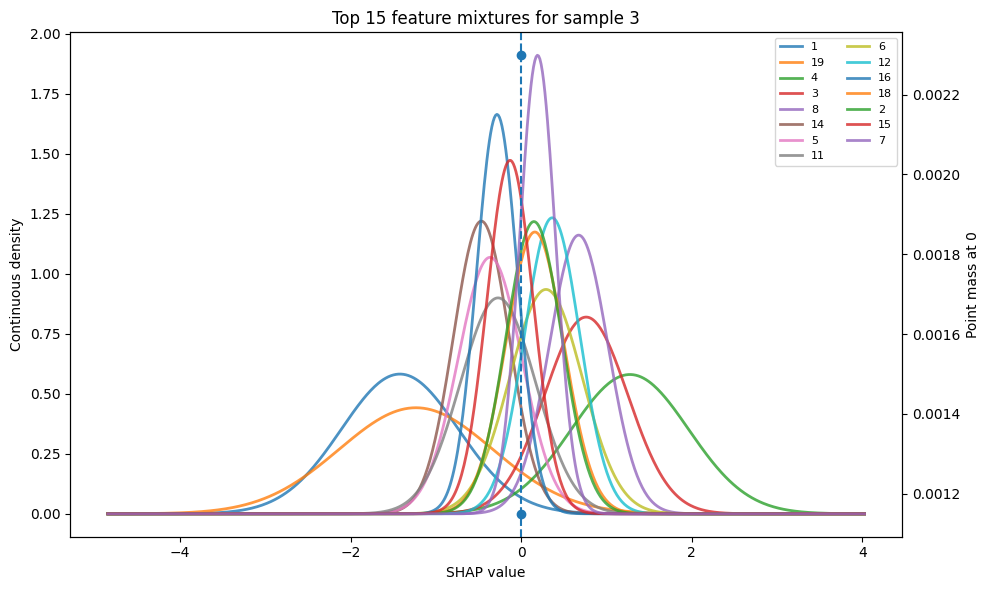

In [25]:
top15_df = plot_top_features_overlay(
    mix_df=mix_df1_3,
    sample_id=sample_id,
    top_k=15,
    rank_by="mean_abs_mixture",
)

In [26]:
feature_sq_df3 = estimate_feature_level_sq_mixture_gamma(
    boot_results=all_boot_results1_3,
    sample_col="sample_id",
    feature_col="feature",
    use_sample_var=True,
)

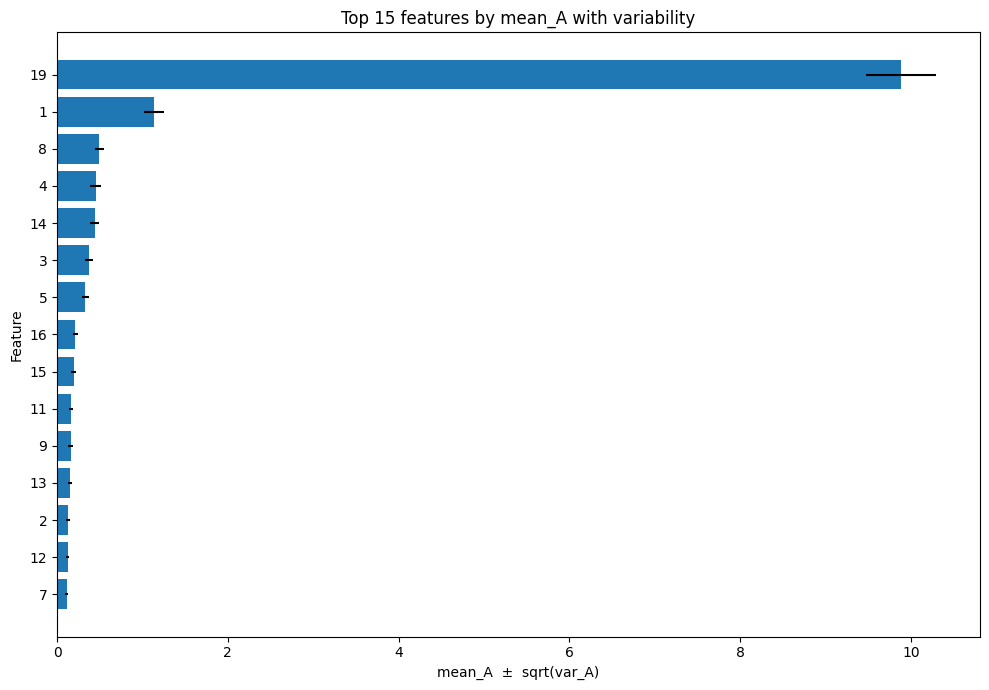

In [27]:
top15_df3 = plot_top15_feature_sq_with_error(
    feature_sq_df3,
    top_k=15,
    score_col="mean_A",
    var_col="var_A",
)

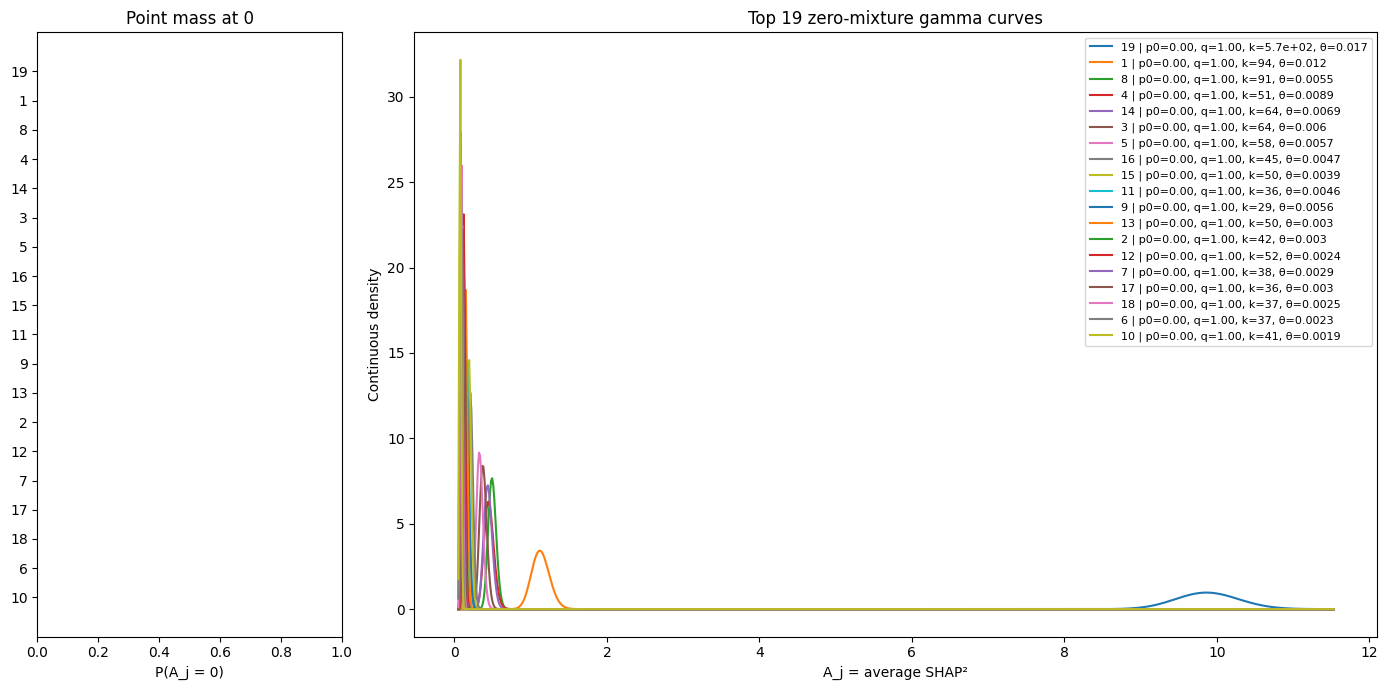

In [28]:
top_df3 = plot_top15_feature_sq_mixture_gamma(
    feature_sq_df3,
    top_k=20,
    score_col="mean_A",
    x_min=5e-2,
    log_x=False,
)

In [74]:
# Clusters with exactly 2 original features
clusters_with_2 = (
    cluster_df.groupby("cluster")["x"]
    .apply(list)
    .loc[lambda s: s.str.len() == 2]
)

print("Clusters with exactly 2 features:")
print(clusters_with_2 if not clusters_with_2.empty else "None")

Clusters with exactly 2 features:
cluster
1    [x0, x1]
Name: x, dtype: object


In [31]:
target_cluster = 14
members = cluster_df.loc[cluster_df["cluster"] == target_cluster, "x"].tolist()
print(f"Cluster {target_cluster} members: {members}")
print(f"Size: {len(members)}")

Cluster 14 members: ['x16']
Size: 1


In [37]:
all_boot_results1_4 = boot_multi_repeat_inference_keep_all(
    X=X_hard,  # drop one feature to test robustness
    y=y_hard,
    task="binary",
    n_bootstrap=100,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats: 100%|██████████| 100/100 [00:00<00:00, 109.22it/s]


In [38]:
mix_df1_4 = estimate_zero_normal_mixture(all_boot_results1_4)

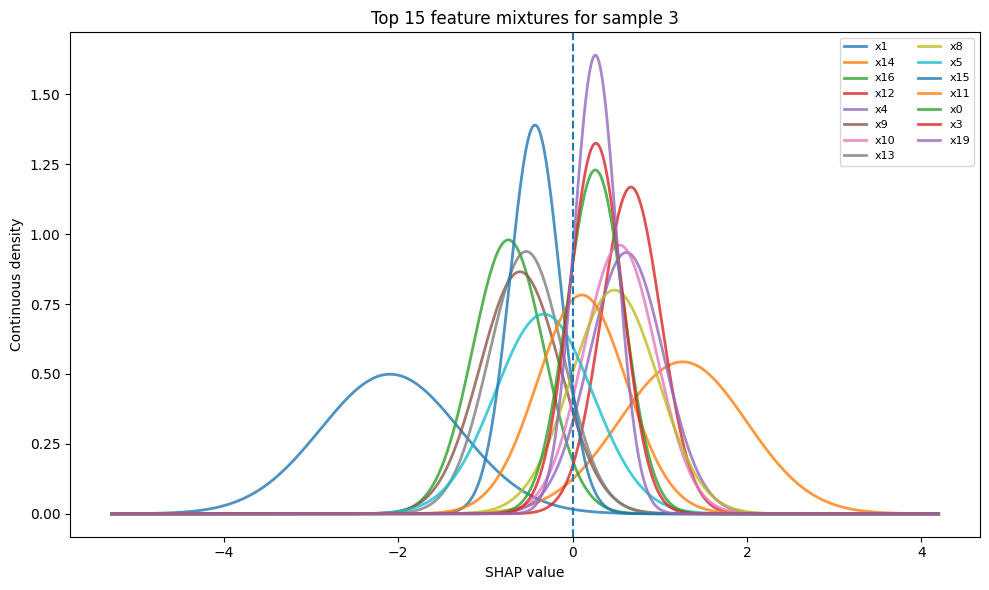

In [39]:
top15_df = plot_top_features_overlay(
    mix_df=mix_df1_4,
    sample_id=sample_id,
    top_k=15,
    rank_by="mean_abs_mixture",
)

In [40]:
feature_sq_df4 = estimate_feature_level_sq_mixture_gamma(
    boot_results=all_boot_results1_4,
    sample_col="sample_id",
    feature_col="feature",
    use_sample_var=True,
)

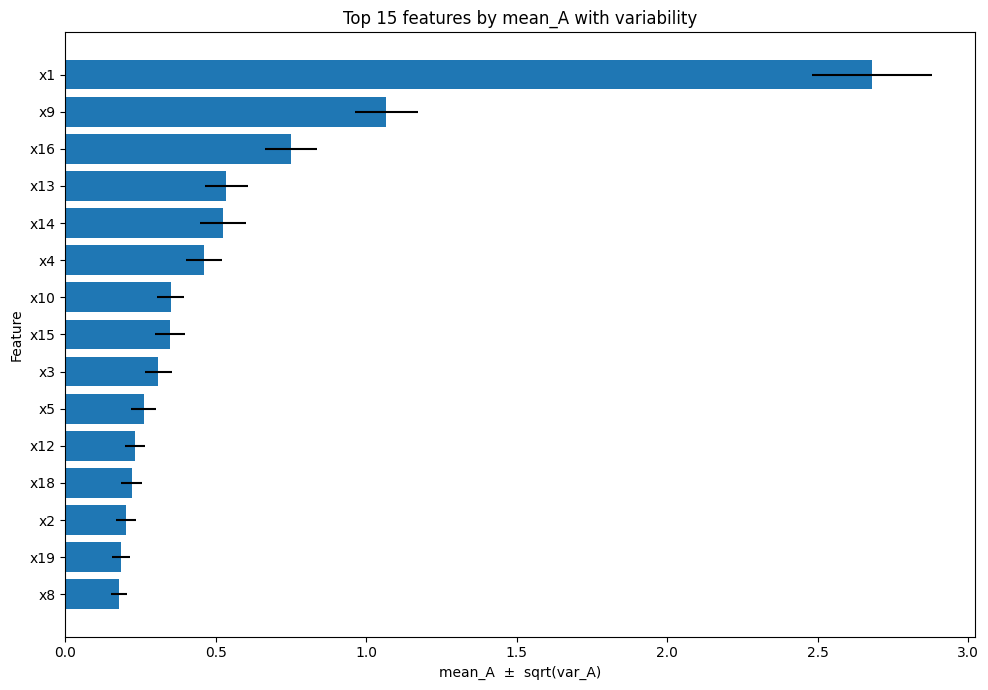

In [41]:
top15_df4 = plot_top15_feature_sq_with_error(
    feature_sq_df4,
    top_k=15,
    score_col="mean_A",
    var_col="var_A",
)

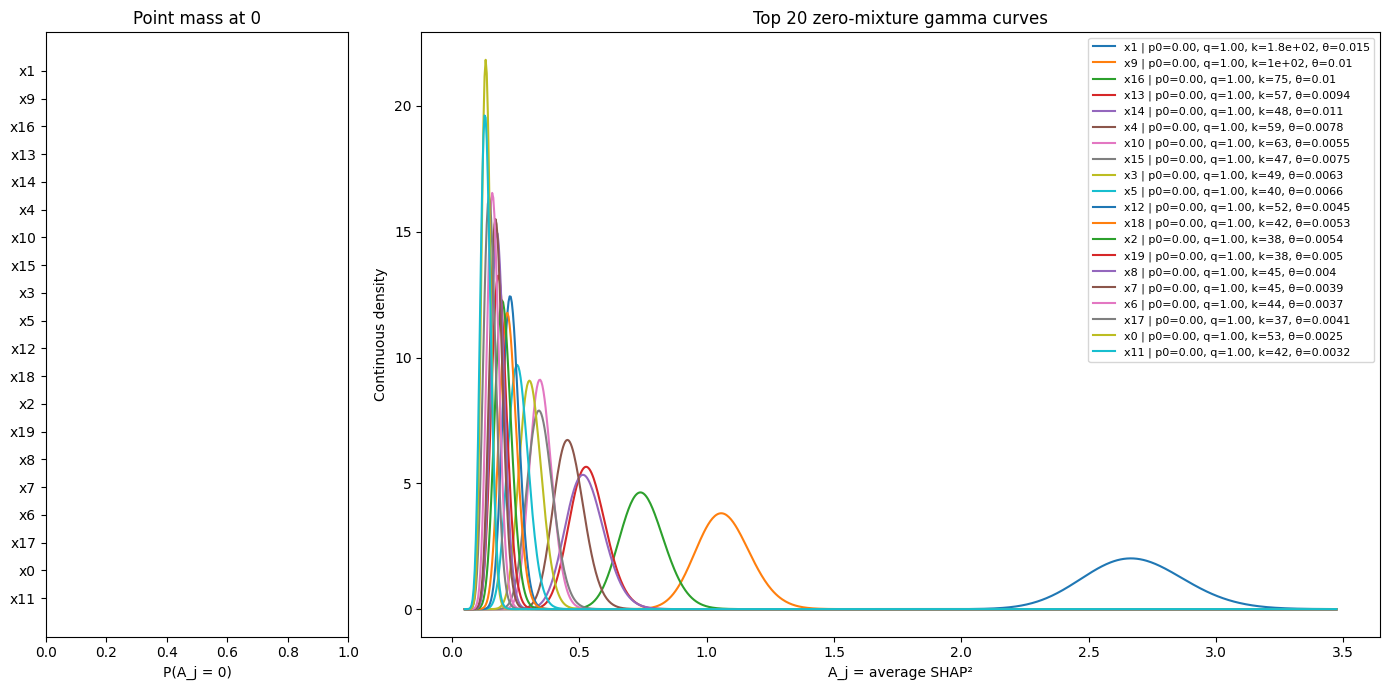

In [42]:
top_df4 = plot_top15_feature_sq_mixture_gamma(
    feature_sq_df4,
    top_k=20,
    score_col="mean_A",
    x_min=5e-2,
    log_x=False,
)

In [43]:
feature_sq_df4

,feature,n_samples_used,n_zero_samples,n_nonzero_samples,sum_mean_x2,sum_var_x2,N,mean_A,var_A,sd_A,...,p_nonzero,mean_sum,var_sum,second_moment_A,pos_mean_A,pos_var_A,pos_sd_A,gamma_shape,gamma_scale,pos_median_A
0,x0,100,0.0,100.0,13.414399,3.391875,100,0.134144,0.000339,0.018417,...,1.0,13.414399,3.391875,0.018334,0.134144,0.000339,0.018417,53.052107,0.002529,0.133302
1,x1,100,0.0,100.0,268.083556,393.234704,100,2.680836,0.039323,0.198301,...,1.0,268.083556,393.234704,7.226203,2.680836,0.039323,0.198301,182.763098,0.014668,2.675948
2,x2,100,0.0,100.0,20.167711,10.805439,100,0.201677,0.001081,0.032872,...,1.0,20.167711,10.805439,0.041754,0.201677,0.001081,0.032872,37.641836,0.005358,0.199894
3,x3,100,0.0,100.0,30.973689,19.624959,100,0.309737,0.001962,0.044300,...,1.0,30.973689,19.624959,0.097899,0.309737,0.001962,0.044300,48.885166,0.006336,0.307627
4,x4,100,0.0,100.0,46.046975,35.687140,100,0.460470,0.003569,0.059739,...,1.0,46.046975,35.687140,0.215601,0.460470,0.003569,0.059739,59.414229,0.007750,0.457889
5,x5,100,0.0,100.0,26.158791,17.251250,100,0.261588,0.001725,0.041535,...,1.0,26.158791,17.251250,0.070153,0.261588,0.001725,0.041535,39.665670,0.006595,0.259393
6,x6,100,0.0,100.0,16.128942,5.926583,100,0.161289,0.000593,0.024345,...,1.0,16.128942,5.926583,0.026607,0.161289,0.000593,0.024345,43.894224,0.003675,0.160066
7,x7,100,0.0,100.0,17.398471,6.746668,100,0.173985,0.000675,0.025974,...,1.0,17.398471,6.746668,0.030945,0.173985,0.000675,0.025974,44.867596,0.003878,0.172694
8,x8,100,0.0,100.0,17.952097,7.194907,100,0.179521,0.000719,0.026823,...,1.0,17.952097,7.194907,0.032947,0.179521,0.000719,0.026823,44.792486,0.004008,0.178187
9,x9,100,0.0,100.0,106.727699,110.549192,100,1.067277,0.011055,0.105142,...,1.0,106.727699,110.549192,1.150135,1.067277,0.011055,0.105142,103.038308,0.010358,1.063826


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
import shap

In [36]:
def compare_methods(X, y, true_ranking=['x2', 'x3', 'x1', 'x0']):
    results = {}
    
    # 1. IG
    ig = mutual_info_classif(X, y, random_state=42)
    results['IG'] = pd.Series(ig, index=X.columns).sort_values(ascending=False)
    
    # 2. LR coefficients
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X, y)
    coef = pd.Series(np.abs(lr.coef_).mean(axis=0), index=X.columns)
    results['Coef'] = coef.sort_values(ascending=False)
    
    # 3. LinearSHAP
    explainer = shap.LinearExplainer(lr, X)
    sv = explainer.shap_values(X)
    if isinstance(sv, list):
        shap_vals = pd.Series(
            sum(np.abs(s) for s in sv).mean(axis=0), index=X.columns
        )
    else:
        shap_vals = pd.Series(np.abs(sv).mean(axis=0), index=X.columns)
    results['SHAP_LR'] = shap_vals.sort_values(ascending=False)
    
    # 4. XGBoost SHAP
    import xgboost as xgb
    dtrain = xgb.DMatrix(X, label=y)
    xgb_model = xgb.train(
        {'objective': 'binary:logistic', 'max_depth': 20,
         'learning_rate': 0.1, 'seed': 6},
        dtrain, num_boost_round=100, verbose_eval=False
    )
    sv_xgb = xgb_model.predict(dtrain, pred_contribs=True)[:, :-1]
    results['SHAP_XGB'] = pd.Series(
        np.abs(sv_xgb).mean(axis=0), index=X.columns
    ).sort_values(ascending=False)
    
    # 5. LOCO
    from sklearn.metrics import roc_auc_score
    baseline = roc_auc_score(y, lr.predict_proba(X)[:, 1])
    loco = {}
    for feat in X.columns:
        X_loco = X.copy()
        X_loco[feat] = X[feat].mean()
        loco[feat] = baseline - roc_auc_score(y, lr.predict_proba(X_loco)[:, 1])
    results['LOCO'] = pd.Series(loco).sort_values(ascending=False)
    
    # Print rankings
    print(f"True ranking: {true_ranking}\n")
    for method, scores in results.items():
        ranking = scores.index.tolist()
        correct = ranking == true_ranking
        print(f"{method:12s}: {ranking}  {'✓' if correct else '✗'}")
        print(f"{'':12s}  scores: {scores.round(3).tolist()}")
    
    return results

results = compare_methods(X_hard, y_hard)

True ranking: ['x2', 'x3', 'x1', 'x0']

IG          : ['x1', 'x6', 'x16', 'x18', 'x13', 'x0', 'x10', 'x14', 'x9', 'x2', 'x3', 'x4', 'x11', 'x8', 'x5', 'x7', 'x15', 'x12', 'x17', 'x19']  ✗
              scores: [0.08, 0.073, 0.054, 0.054, 0.034, 0.032, 0.014, 0.006, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Coef        : ['x1', 'x9', 'x3', 'x16', 'x14', 'x4', 'x13', 'x0', 'x12', 'x2', 'x15', 'x10', 'x8', 'x5', 'x19', 'x18', 'x6', 'x17', 'x7', 'x11']  ✗
              scores: [1.124, 0.56, 0.439, 0.403, 0.39, 0.351, 0.329, 0.307, 0.281, 0.262, 0.232, 0.152, 0.143, 0.137, 0.132, 0.091, 0.068, 0.047, 0.011, 0.01]
SHAP_LR     : ['x1', 'x9', 'x3', 'x14', 'x16', 'x4', 'x13', 'x0', 'x12', 'x2', 'x15', 'x10', 'x8', 'x5', 'x19', 'x18', 'x6', 'x17', 'x7', 'x11']  ✗
              scores: [0.916, 0.441, 0.367, 0.327, 0.321, 0.277, 0.262, 0.246, 0.228, 0.209, 0.188, 0.123, 0.111, 0.109, 0.107, 0.071, 0.053, 0.036, 0.009, 0.008]
SHAP_XGB    : ['x1', 'x9', 'x15', 'x14', 'x10', 'x16'

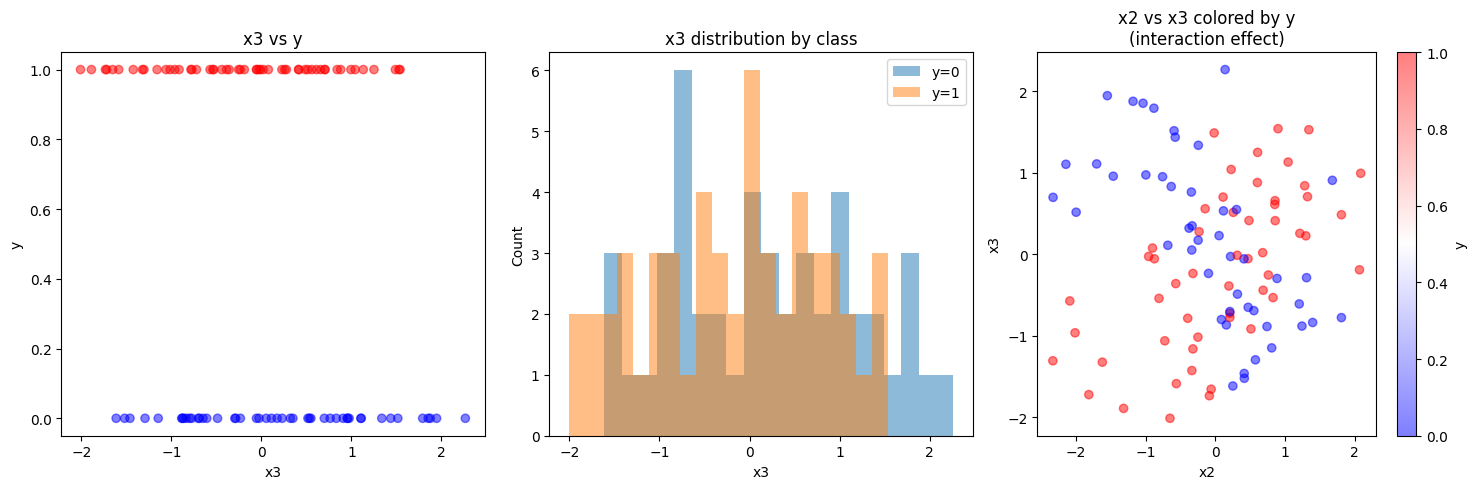

Marginal stats:
  corr(x3, y): -0.1814
  corr(x2, y): 0.0943
  corr(x2*x3, y): 0.5906


In [37]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: x3 vs y (raw values)
axes[0].scatter(X_hard['x3'], y_hard, alpha=0.5, c=y_hard, cmap='bwr')
axes[0].set_xlabel('x3')
axes[0].set_ylabel('y')
axes[0].set_title('x3 vs y')

# Plot 2: x3 distribution by class
axes[1].hist(X_hard['x3'][y_hard==0], alpha=0.5, label='y=0', bins=20)
axes[1].hist(X_hard['x3'][y_hard==1], alpha=0.5, label='y=1', bins=20)
axes[1].set_xlabel('x3')
axes[1].set_ylabel('Count')
axes[1].set_title('x3 distribution by class')
axes[1].legend()

# Plot 3: x2*x3 interaction vs y
scatter = axes[2].scatter(X_hard['x2'], X_hard['x3'], 
                          c=y_hard, cmap='bwr', alpha=0.5)
plt.colorbar(scatter, ax=axes[2], label='y')
axes[2].set_xlabel('x2')
axes[2].set_ylabel('x3')
axes[2].set_title('x2 vs x3 colored by y\n(interaction effect)')

plt.tight_layout()
plt.show()

# Print marginal stats
print("Marginal stats:")
print(f"  corr(x3, y): {np.corrcoef(X_hard['x3'], y_hard)[0,1]:.4f}")
print(f"  corr(x2, y): {np.corrcoef(X_hard['x2'], y_hard)[0,1]:.4f}")
print(f"  corr(x2*x3, y): {np.corrcoef(X_hard['x2']*X_hard['x3'], y_hard)[0,1]:.4f}")

corr(x9, y): -0.2235


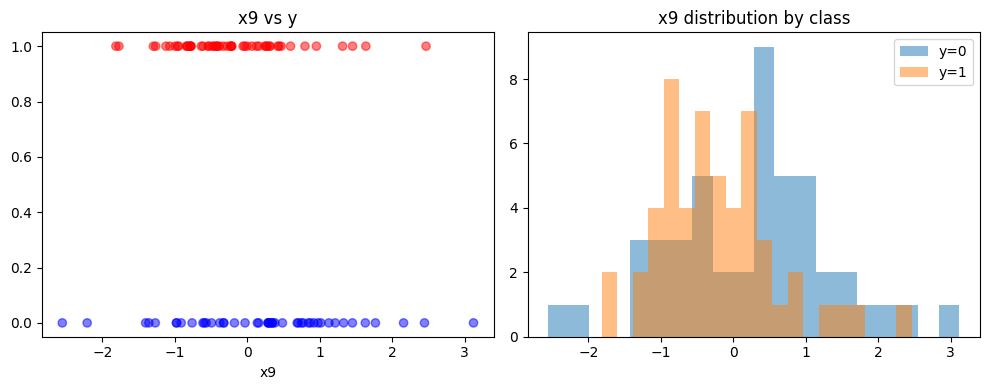

In [38]:
print(f"corr(x9, y): {np.corrcoef(X_hard['x9'], y_hard)[0,1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_hard['x9'], y_hard, alpha=0.5, c=y_hard, cmap='bwr')
axes[0].set_title('x9 vs y')
axes[0].set_xlabel('x9')

axes[1].hist(X_hard['x9'][y_hard==0], alpha=0.5, label='y=0', bins=20)
axes[1].hist(X_hard['x9'][y_hard==1], alpha=0.5, label='y=1', bins=20)
axes[1].set_title('x9 distribution by class')
axes[1].legend()
plt.tight_layout()
plt.show()

In [40]:
feature_sq_df2

,feature,n_samples_used,n_zero_samples,n_nonzero_samples,sum_mean_x2,sum_var_x2,N,mean_A,var_A,sd_A,p_all_zero,p_nonzero,mean_sum,var_sum,second_moment_A,pos_mean_A,pos_var_A,pos_sd_A,gamma_shape,gamma_scale
0,x0,300,0.0,300.0,982.187894,2908.909597,300,3.273960,0.032321,0.179781,0.0,1.0,982.187894,2908.909597,10.751133,3.273960,0.032321,0.179781,331.633909,0.009872
1,x2,300,0.0,300.0,3435.222824,11586.702813,300,11.450743,0.128741,0.358805,0.0,1.0,3435.222824,11586.702813,131.248251,11.450743,0.128741,0.358805,1018.474025,0.011243
2,x3,300,0.0,300.0,4004.609949,9007.426447,300,13.348700,0.100083,0.316358,0.0,1.0,4004.609949,9007.426447,178.287870,13.348700,0.100083,0.316358,1780.408748,0.007498


In [41]:
feature_sq_df3

,feature,n_samples_used,n_zero_samples,n_nonzero_samples,sum_mean_x2,sum_var_x2,N,mean_A,var_A,sd_A,p_all_zero,p_nonzero,mean_sum,var_sum,second_moment_A,pos_mean_A,pos_var_A,pos_sd_A,gamma_shape,gamma_scale
0,x0,100,0.0,100.0,50.288495,44.068463,100,0.502885,0.004407,0.066384,0.0,1.0,50.288495,44.068463,0.257300,0.502885,0.004407,0.066384,57.386451,0.008763
1,x1,100,0.0,100.0,87.886470,129.893511,100,0.878865,0.012989,0.113971,0.0,1.0,87.886470,129.893511,0.785393,0.878865,0.012989,0.113971,59.464337,0.014780
2,x4,100,0.0,100.0,21.906822,11.239495,100,0.219068,0.001124,0.033525,0.0,1.0,21.906822,11.239495,0.049115,0.219068,0.001124,0.033525,42.698436,0.005131
3,x5,100,0.0,100.0,24.287983,11.880160,100,0.242880,0.001188,0.034468,0.0,1.0,24.287983,11.880160,0.060179,0.242880,0.001188,0.034468,49.654727,0.004891
4,x6,100,0.0,100.0,31.438375,19.459324,100,0.314384,0.001946,0.044113,0.0,1.0,31.438375,19.459324,0.100783,0.314384,0.001946,0.044113,50.791662,0.006190
5,x7,100,0.0,100.0,20.727990,8.697648,100,0.207280,0.000870,0.029492,0.0,1.0,20.727990,8.697648,0.043835,0.207280,0.000870,0.029492,49.398358,0.004196
6,x8,100,0.0,100.0,32.544768,20.260794,100,0.325448,0.002026,0.045012,0.0,1.0,32.544768,20.260794,0.107942,0.325448,0.002026,0.045012,52.276427,0.006226
7,x9,100,0.0,100.0,56.986900,42.340762,100,0.569869,0.004234,0.065070,0.0,1.0,56.986900,42.340762,0.328985,0.569869,0.004234,0.065070,76.699299,0.007430
8,x10,100,0.0,100.0,99.270441,134.238179,100,0.992704,0.013424,0.115861,0.0,1.0,99.270441,134.238179,0.998886,0.992704,0.013424,0.115861,73.411458,0.013522
9,x11,100,0.0,100.0,25.985890,14.414522,100,0.259859,0.001441,0.037966,0.0,1.0,25.985890,14.414522,0.068968,0.259859,0.001441,0.037966,46.846263,0.005547


In [42]:
seed_importance_df1 = seed_importance(
    X=X_simple1,
    y=y_simple1,
    b_model=200,
    params=params)

KeyboardInterrupt: 

In [ ]:
target_features = ["x0", "x1", "x2", "x3"]

seed_importance_df1.loc[
    seed_importance_df1["feature"].isin(target_features) & (seed_importance_df1["rank_order"] <= 4)
].groupby("feature").size().reindex(target_features, fill_value=0)

feature
x0    200
x1    200
x2    200
x3    200
dtype: int64

In [ ]:
target_features = ["x0", "x1", "x2", "x3"]

other_top4_counts = (
    seed_importance_df1.loc[
        (~seed_importance_df1["feature"].isin(target_features)) & (seed_importance_df1["rank_order"] <= 4)
    ]
    .groupby("feature")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_times_in_top4")
)

other_top4_counts.head(20)

,feature,n_times_in_top4


In [54]:
(
    seed_importance_df1.pivot(index="run", columns="feature", values="rank_order")
    .assign(x1_higher_than_x0=lambda d: d["x2"] < d["x3"])
    ["x1_higher_than_x0"]
    .sum()
)

199

In [ ]:
(seed_importance_df1.loc[seed_importance_df1["feature"] == "x2", "rank_order"] != 1).sum()

199

In [73]:
seed_importance_df1

,run,feature,mean_abs_shap,test_accuracy,rank,rank_order
0,0,x2,2.184079,0.750000,1.0,1
1,0,x3,1.854671,0.750000,2.0,2
2,0,x0,1.404730,0.750000,3.0,3
3,0,x1,1.352738,0.750000,4.0,4
4,1,x2,2.385441,0.800000,1.0,1
...,...,...,...,...,...,...
795,198,x1,1.320990,0.750000,4.0,4
796,199,x2,2.229028,0.816667,1.0,1
797,199,x3,1.737265,0.816667,2.0,2
798,199,x1,1.459498,0.816667,3.0,3


In [56]:
rank_var_df = (
    seed_importance_df1.groupby("feature", as_index=False)
    .agg(
        rank_mean=("rank_order", "mean"),
        rank_var=("rank_order", "var"),
        rank_sd=("rank_order", "std"),
        n_runs=("rank_order", "size"),
    )
    .sort_values("rank_var", ascending=False)
    .reset_index(drop=True)
)
rank_var_df

,feature,rank_mean,rank_var,rank_sd,n_runs
0,x1,2.895,0.225101,0.474448,200
1,x3,2.155,0.141683,0.376409,200
2,x0,3.940,0.056683,0.238083,200
3,x2,1.010,0.009950,0.099748,200


## Example 2-more noise and correlation

In [62]:
X_simple2, y_simple2, meta_simple = simulate_binary_data_controlled(
    n_samples=300,          # N
    n_features=20,          # p, default p < N
    important_idx=(0, 1, 2, 3),
    correlated_pair=(0, 1), # these two will be highly correlated and important
    rho=0.6,                # target correlation for the pair
    signal_strength=1.0,
    noise_scale=0.25,
    random_state=42,
)

print(X_simple2.shape)
print(y_simple2.value_counts())

(300, 20)
y
1    156
0    144
Name: count, dtype: int64


In [63]:
all_boot_results2 = boot_multi_repeat_inference_keep_all(
    X=X_simple2,
    y=y_simple2,
    n_bootstrap=200,
    b_model=50,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True,
    return_as="dataframe",
)

Bootstrap repeats: 100%|██████████| 200/200 [00:57<00:00,  3.49it/s]


In [64]:
mix_df2 = estimate_zero_normal_mixture(all_boot_results2)

In [65]:
feature_sq_df2 = estimate_feature_level_sq_mixture_gamma(
    df=all_boot_results2,
    sample_col="sample_id",
    feature_col="feature",
    use_sample_var=True,
)

/opt/miniconda3/envs/emotion-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


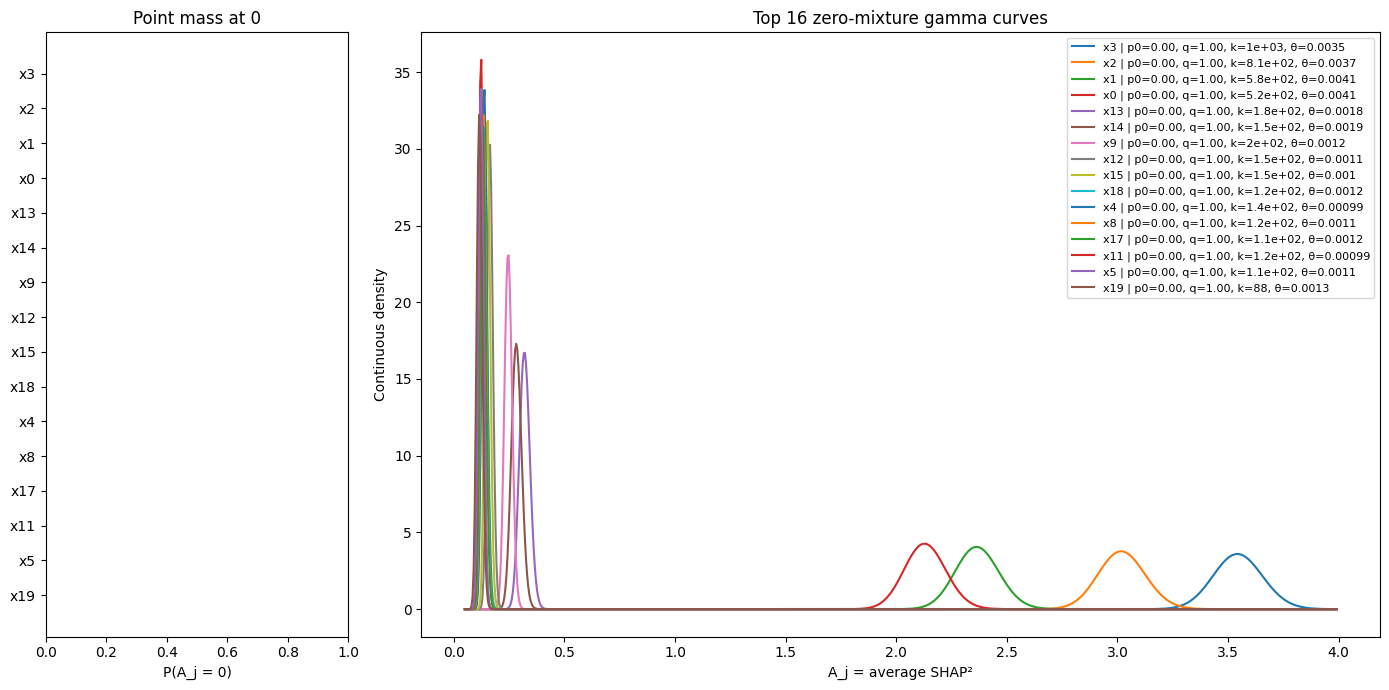

In [66]:
top_df2 = plot_top15_feature_sq_mixture_gamma(
    feature_sq_df2,
    top_k=16,
    score_col="mean_A",
    x_min=5e-2,
    log_x=False,
)

In [67]:
seed_importance_df2 = seed_importance(
    X=X_simple2,
    y=y_simple2,
    b_model=200,
    params=params)

In [68]:
target_features = ["x0", "x1", "x2", "x3"]

seed_importance_df2.loc[
    seed_importance_df2["feature"].isin(target_features) & (seed_importance_df2["rank_order"] <= 4)
].groupby("feature").size().reindex(target_features, fill_value=0)

feature
x0    200
x1    200
x2    200
x3    200
dtype: int64

In [69]:
target_features = ["x0", "x1", "x2", "x3"]

other_top4_counts = (
    seed_importance_df2.loc[
        (~seed_importance_df2["feature"].isin(target_features)) & (seed_importance_df2["rank_order"] <= 4)
    ]
    .groupby("feature")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_times_in_top4")
)

other_top4_counts.head(20)

,feature,n_times_in_top4


In [70]:
(seed_importance_df2.loc[seed_importance_df2["feature"] == "x3", "rank_order"] != 1).sum()

0

In [71]:
(
    seed_importance_df2.pivot(index="run", columns="feature", values="rank_order")
    .assign(x1_higher_than_x0=lambda d: d["x1"] < d["x0"])
    ["x1_higher_than_x0"]
    .sum()
)

3

In [72]:
rank_var_df = (
    seed_importance_df2.groupby("feature", as_index=False)
    .agg(
        rank_mean=("rank_order", "mean"),
        rank_var=("rank_order", "var"),
        rank_sd=("rank_order", "std"),
        n_runs=("rank_order", "size"),
    )
    .sort_values("rank_var", ascending=False)
    .reset_index(drop=True)
)
rank_var_df

,feature,rank_mean,rank_var,rank_sd,n_runs
0,x18,15.030,7.566935,2.750806,200
1,x7,15.545,7.565804,2.750601,200
2,x15,13.075,7.516960,2.741707,200
3,x17,13.065,7.468116,2.732785,200
4,x16,16.430,6.809146,2.609434,200
5,x6,16.185,6.734447,2.595081,200
6,x5,11.980,6.331256,2.516199,200
7,x8,15.005,6.125603,2.474996,200
8,x4,9.605,6.099472,2.469711,200
9,x14,9.110,4.691357,2.165954,200


## Eample 3

In [33]:
X_simple3, y_simple3, meta_simple = simulate_binary_data_controlled(
    n_samples=10000,          # N
    n_features=20,          # p, default p < N
    important_idx=(0, 1, 2, 3),
    correlated_pair=(0, 1), # these two will be highly correlated and important
    rho=0.6,                # target correlation for the pair
    signal_strength=1.0,
    noise_scale=0.2,
    random_state=42,
)

print(X_simple3.shape)
print(y_simple3.value_counts())

(10000, 20)
y
1    5156
0    4844
Name: count, dtype: int64


In [26]:
seed_importance_df3 = seed_importance(
    X=X_simple3,
    y=y_simple3,
    b_model=200,
    params=params)

In [27]:
target_features = ["x0", "x1", "x2", "x3"]

seed_importance_df3.loc[
    seed_importance_df3["feature"].isin(target_features) & (seed_importance_df3["rank_order"] <= 4)
].groupby("feature").size().reindex(target_features, fill_value=0)

feature
x0    200
x1    200
x2    200
x3    200
dtype: int64

In [28]:
target_features = ["x0", "x1", "x2", "x3"]

other_top4_counts = (
    seed_importance_df3.loc[
        (~seed_importance_df3["feature"].isin(target_features)) & (seed_importance_df3["rank_order"] <= 4)
    ]
    .groupby("feature")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_times_in_top4")
)

other_top4_counts.head(20)

,feature,n_times_in_top4


In [29]:
(
    seed_importance_df3.pivot(index="run", columns="feature", values="rank_order")
    .assign(x1_higher_than_x0=lambda d: d["x1"] < d["x0"])
    ["x1_higher_than_x0"]
    .sum()
)

28

In [30]:
(seed_importance_df3.loc[seed_importance_df3["feature"] == "x2", "rank_order"] != 1).sum()

0

In [31]:
rank_var_df = (
    seed_importance_df3.groupby("feature", as_index=False)
    .agg(
        rank_mean=("rank_order", "mean"),
        rank_var=("rank_order", "var"),
        rank_sd=("rank_order", "std"),
        n_runs=("rank_order", "size"),
    )
    .sort_values("rank_var", ascending=False)
    .reset_index(drop=True)
)


In [32]:
rank_var_df

,feature,rank_mean,rank_var,rank_sd,n_runs
0,x0,3.135,0.127412,0.356948,200
1,x1,3.860,0.121005,0.347858,200
2,x3,2.005,0.005000,0.070711,200
3,x2,1.000,0.000000,0.000000,200
